In [2]:
from xmitgcm import open_mdsdataset
import xmitgcm 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import xarray as xr
import cmocean
import pylab as pl
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation
import ffmpeg
from matplotlib import animation
from matplotlib.gridspec import GridSpec

from mpl_toolkits.axes_grid1 import make_axes_locatable

import MITgcmutils
import math
import netCDF4 as nc
from scipy.io import savemat
import scipy as sc
import scipy.io as sio
import scipy.interpolate as sciint
import warnings
import datetime
warnings.filterwarnings("ignore")

In [3]:
project='2DsillOB'
ed='run/'

location='/Users/ameliaking/Proyecto/Codigo/NGC/'+ str(project) + '/Files/' + str(ed) #'/Users/ameliaking/Proyecto/Codigo/Idealizada/ChangeDim/'

#location='/home/amelia/NGC/'+ str(project) + '/Files/' + str(ed) #'/Users/ameliaking/Proyecto/Codigo/Idealizada/ChangeDim/'

var='dynDiag'

ds=xr.open_dataset(str(location) +  str(var) + '.nc')


varS='surfDiag'

dsS=xr.open_dataset(str(location) +  str(varS) + '.nc')

varG='grid'

dsG=xr.open_dataset(str(location) +  str(varG) + '.nc')

#Take them minus 1 and 2 to skip the boundary
ny=len(ds.Y)
nx=len(ds.X) 
nz=len(ds.diag_levels)

hFacC = dsG.HFacC

hfa = np.ma.masked_values(hFacC, 0)
mask = np.ma.getmask(hfa)

hFacW = dsG.HFacW

hfaW = np.ma.masked_values(hFacW, 0)
maskw = np.ma.getmask(hfaW)

hFacS = dsG.HFacS

hfaS = np.ma.masked_values(hFacS, 0)
masks = np.ma.getmask(hfaS)

if project == '2Dsill':
    OB=1
    OBend=-1
elif project =='2DsillOB':
    OB=20
    OBend=-1

In [4]:
zind=np.where(dsG.Z>-400)[0][-1]

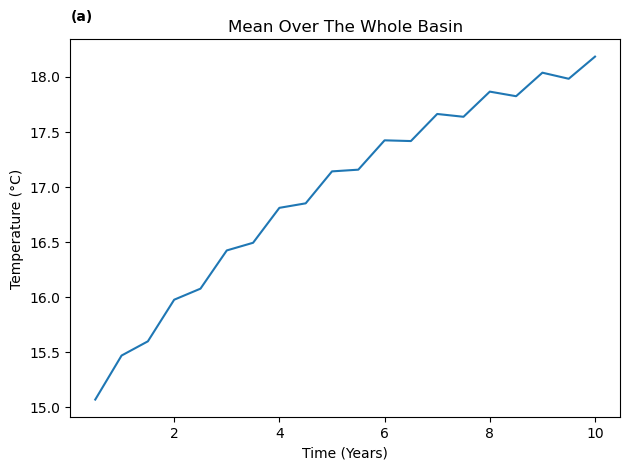

In [5]:
fig,ax=plt.subplots()

ax.plot(ds.T.values/(60*60*24*360),np.mean(np.mean(ds.THETA[:,:zind,OB:OBend,0],axis=1),axis=1))

ax.set(xlabel='Time (Years)',ylabel='Temperature (°C)',title='Mean Over The Whole Basin')

ax.text(0, 1.05, '(a)', fontweight='bold', color='k', 
        transform=ax.transAxes)

fig.tight_layout()
#plt.savefig('../' + str(project)+'/Figures/' +str(ed)+ 'OBCStest.png', bbox_inches='tight')

In [6]:
tin=np.where(ds.T/(24*60*60*360)>7)[0][0]
tinS=np.where(dsS.T/(24*60*60*360)>7)[0][0]

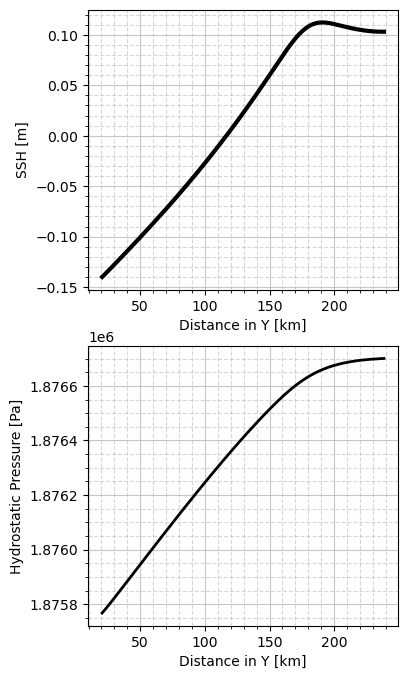

In [27]:
fig,axin=plt.subplots(2)

ax=axin[0]
xlab= 'SSH [m]'#'Meridional Transport of Density (kg/m$^2$/s)'
inarr=dsS.ETAN[:,:,:,:].values

ax.plot(dsS.Y[OB:OBend]/1000,np.mean(inarr[tin:,0,OB:OBend,0],axis=0), linewidth=3,c='k')
ax.set(xlabel='Distance in Y [km]',ylabel=xlab)
ax.minorticks_on()

ax.grid(which='minor',linestyle='--', alpha=0.5)
ax.grid(which='major',alpha=0.7)


#pressure
g=10
rho0=1000
inarr=(np.mean((rho0*np.sum(-g*dsG.Z.values[None,:zind,None] + ds.PHIHYD.values[tin:,:zind,OB:OBend,0],axis=1)),axis=0)+g*rho0*np.mean(dsS.ETAN.values[tinS:,0,OB:OBend,0],axis=0))/(len(dsG.Z[:zind])+1)


ax=axin[1]
xlab= 'Hydrostatic Pressure [Pa]'


ax.plot(dsG.Y[OB:OBend]/1000,inarr, linewidth=2,color='k',label='Total')

ax.set(xlabel='Distance in Y [km]',ylabel=xlab)
ax.minorticks_on()

ax.grid(which='minor',linestyle='--', alpha=0.5)
ax.grid(which='major',alpha=0.7)



In [39]:
dsG

<xarray.Dataset>
Dimensions:  (Z: 80, Zp1: 81, Zu: 80, Zl: 80, X: 1, Y: 240, Xp1: 2, Yp1: 241)
Coordinates:
  * Z        (Z) float64 -7.5 -22.5 -37.5 ... -1.162e+03 -1.178e+03 -1.192e+03
  * Zp1      (Zp1) float64 0.0 -15.0 -30.0 ... -1.17e+03 -1.185e+03 -1.2e+03
  * Zu       (Zu) float64 -15.0 -30.0 -45.0 ... -1.17e+03 -1.185e+03 -1.2e+03
  * Zl       (Zl) float64 0.0 -15.0 -30.0 ... -1.155e+03 -1.17e+03 -1.185e+03
  * X        (X) float64 500.0
  * Y        (Y) float64 500.0 1.5e+03 2.5e+03 ... 2.375e+05 2.385e+05 2.395e+05
  * Xp1      (Xp1) float64 0.0 1e+03
  * Yp1      (Yp1) float64 0.0 1e+03 2e+03 3e+03 ... 2.38e+05 2.39e+05 2.4e+05
Data variables: (12/30)
    RC       (Z) float64 ...
    RF       (Zp1) float64 ...
    RU       (Zu) float64 ...
    RL       (Zl) float64 ...
    drC      (Zp1) float64 ...
    drF      (Z) float64 ...
    ...       ...
    R_low    (Y, X) float64 ...
    Ro_surf  (Y, X) float64 ...
    Depth    (Y, X) float64 ...
    HFacC    (Z, Y, X) float64 1.0 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0 0.0
    HFacW    (Z, Y, Xp1) float64 1.0 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 0.0 0.0
    HFacS    (Z, Yp1, X) float64 0.0 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 0.0 0.0
Attributes: (12/18)
    MITgcm_version:  checkpoint69b
    build_user:      amelia.th
    build_host:      tsunami.cicese.mx
    build_date:      mån mar 24 13:17:18 PDT 2025
    MITgcm_URL:      http://mitgcm.org
    MITgcm_tag_id:   
    ...              ...
    nSy:             1
    nPx:             1
    nPy:             4
    Nx:              1
    Ny:              240
    Nr:              80

In [75]:
params = {'font.size': 10,
          'figure.figsize': (8, 8),
         'font.family':'sans'}
pl.rcParams.update(params)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

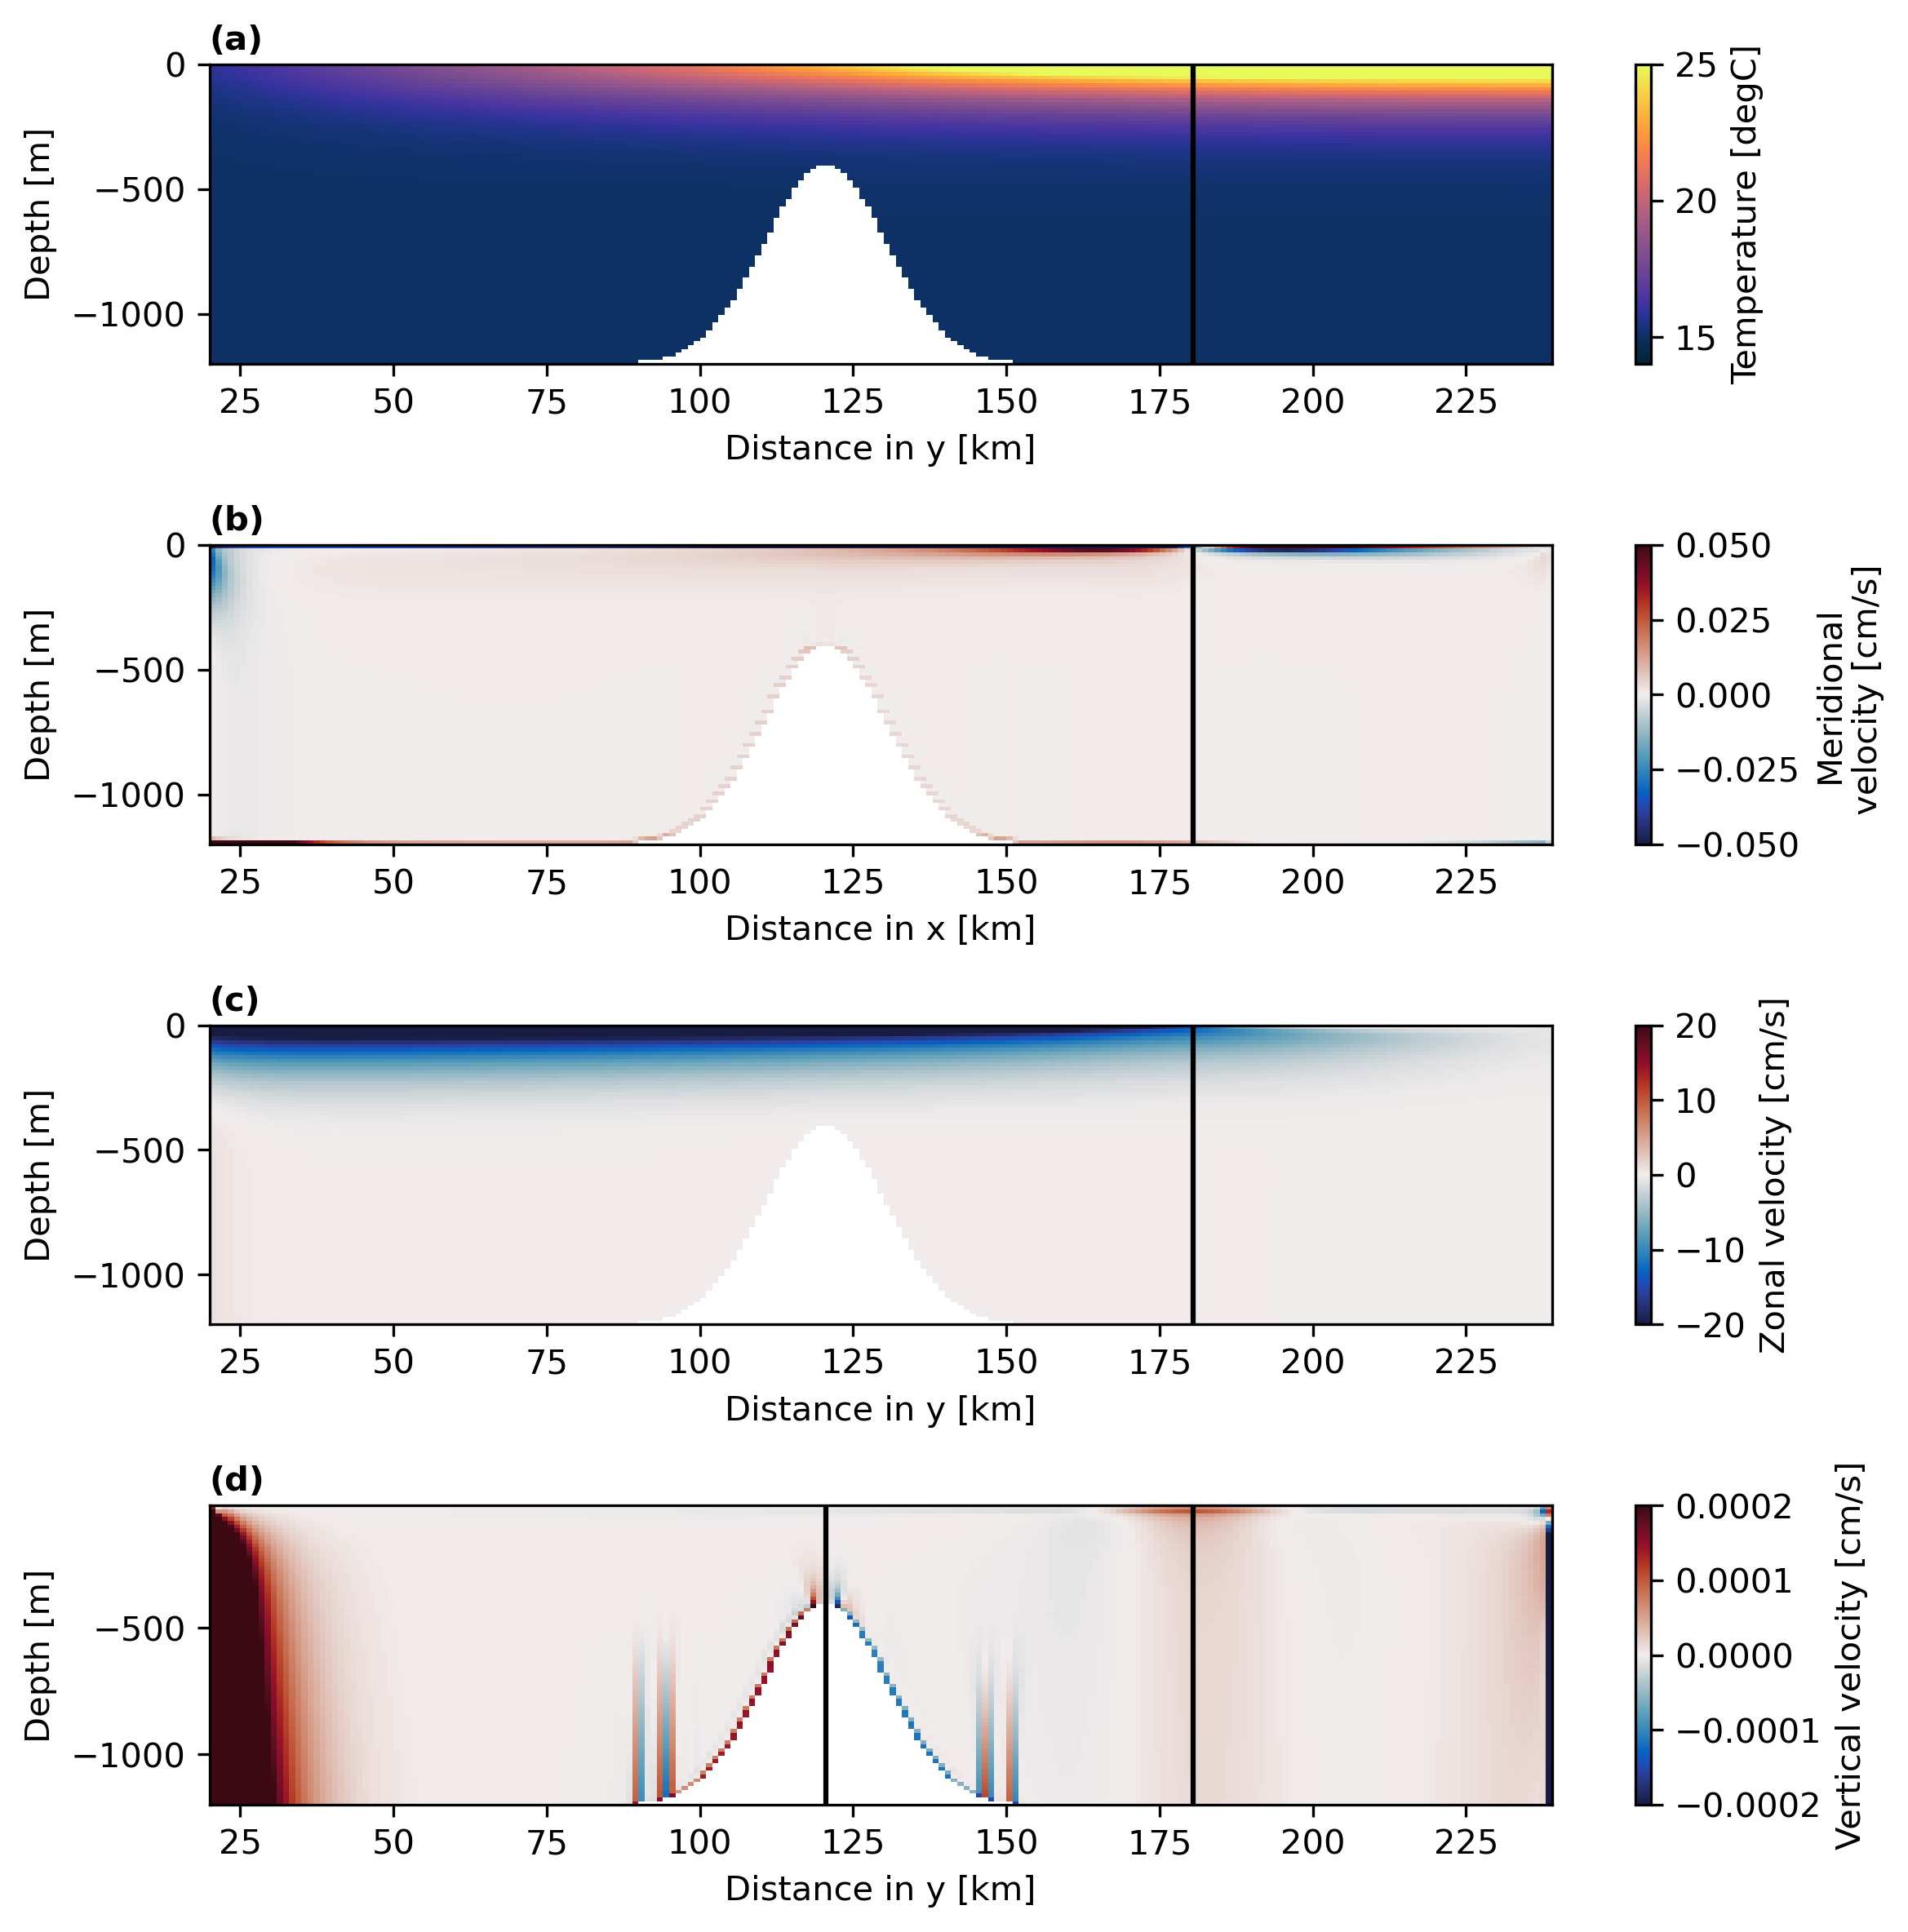

In [76]:

space=8
spacex=2

varin=ds.THETA
title= 'Potential Temperature [°C]'
Yin=dsG.Y[OB:OBend]
Xin=dsG.X
Zin=dsG.Z
vmin=14
vmax=25
cmapi=cmocean.cm.thermal

levels=np.linspace(vmin,vmax,15)

fig = plt.figure()
gs = GridSpec(nrows=4, ncols=1)

axin = fig.add_subplot(gs[0, 0])
axin.set(xlabel='Distance in y [km]')
axin.set(ylabel='Depth [m]')

timein=ds.T[tin]/(60*60*24)
cax0=axin.pcolormesh(Yin/1000, Zin, np.ma.masked_array(np.mean(varin[tin:,:,OB:OBend,0],axis=0),mask=mask[:,OB:OBend,0]),vmin=vmin,vmax=vmax,cmap=cmapi)

cbar_ax = plt.colorbar(cax0)
cbar_ax.set_label('Temperature [degC]')
axin.axvline(ds.Y[int(0.75*ny)]/1000,c='k')

axin.text(0, 1.05, '(a)', fontweight='bold', color='k', 
        transform=axin.transAxes)


axin = fig.add_subplot(gs[1, 0])

gridZ,gridY=np.meshgrid(dsG.Z.values,dsG.Y.values)

interpV=sciint.RegularGridInterpolator((dsG.Z.values,dsG.Yp1.values),np.mean(ds.VVEL[tin:,:,:,0].values,axis=0))
V=interpV((gridZ,gridY))

title= ds.VVEL.description 
Yin=ds.Y[OB:OBend]
Xin=ds.X
vmin=-0.05
vmax=0.05
cmapi=cmocean.cm.balance

levels=np.linspace(vmin,vmax,15)

axin.set(xlabel='Distance in x [km]')
axin.set(ylabel='Depth [m]')

timein=ds.T[-tin]/(60*60*24)
cax0=axin.pcolormesh(Yin/1000, Zin, np.ma.masked_array(V[OB:OBend,:].T*100,mask=mask[:,OB:OBend,0]),vmin=vmin,vmax=vmax,cmap=cmapi)

cbar_ax = plt.colorbar(cax0)
axin.axvline(ds.Y[int(0.75*ny)]/1000,c='k')
cbar_ax.set_label('Meridional\n velocity [cm/s]')


varin=ds.UVEL
title= varin.description 
Yin=ds.Y[OB:OBend]
Xin=ds.Xp1
vmin=-20
vmax=20
cmapi=cmocean.cm.balance

levels=np.linspace(vmin,vmax,15)

axin.text(0, 1.05, '(b)', fontweight='bold', color='k', 
        transform=axin.transAxes)
        
axin = fig.add_subplot(gs[2, 0])

axin.set(xlabel='Distance in y [km]')
axin.set(ylabel='Depth [m]')

timein=ds.T[-tin]/(60*60*24)
cax0=axin.pcolormesh(Yin/1000, Zin, np.ma.masked_array(np.mean(np.mean(varin[tin:,:,OB:OBend,:],axis=0),axis=2)*100,mask=maskw[:,OB:OBend,0]),vmin=vmin,vmax=vmax,cmap=cmapi)

cbar_ax = plt.colorbar(cax0)
cbar_ax.set_label('Zonal velocity [cm/s]')

axin.axvline(ds.Y[int(0.75*ny)]/1000,c='k')
axin.text(0, 1.05, '(c)', fontweight='bold', color='k', 
        transform=axin.transAxes)


gridZ,gridY=np.meshgrid(dsG.Z[1:].values,dsG.Y.values)

interpV=sciint.RegularGridInterpolator((dsG.Zu.values,dsG.Y.values),np.mean(ds.WVEL[tin:,:,:,0].values,axis=0))
varin=interpV((gridZ,gridY))

title= ds.WVEL.description 
Yin=dsG.Y[OB:OBend]
Xin=ds.X
Zin=dsG.Z
vmin=-2e-4
vmax=2e-4
cmapi=cmocean.cm.balance
levels=np.linspace(vmin,vmax,15)

axin = fig.add_subplot(gs[3, 0])

axin.set(xlabel='Distance in y [km]')
axin.set(ylabel='Depth [m]')

timein=ds.T[-tin]/(60*60*24)
cax1=axin.pcolormesh(Yin/1000, Zin[1:], np.ma.masked_array(varin[OB:OBend,:].T*100,mask=mask[1:,OB:OBend,0]),vmin=vmin,vmax=vmax,cmap=cmapi)

cbar_ax = plt.colorbar(cax1)
cbar_ax.set_label('Vertical velocity [cm/s]')

axin.axvline(ds.Y[int(0.75*ny)]/1000,c='k')

axin.axvline(ds.Y[int(0.5*ny)]/1000,c='k')

axin.text(0, 1.05, '(d)', fontweight='bold', color='k', 
        transform=axin.transAxes)

fig.tight_layout()

#plt.savefig('../' + str(project)+'/Figures/Figure1.png', bbox_inches='tight')


In [69]:
params = {'font.size': 10,
          'figure.figsize': (4, 8),
         'font.family':'sans'}
pl.rcParams.update(params)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 100

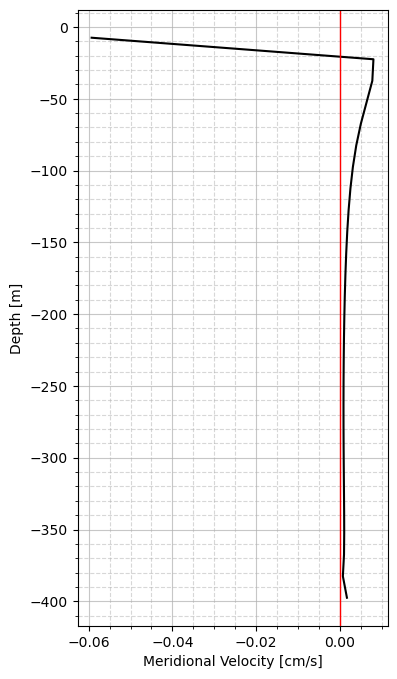

In [74]:
plt.plot(np.ma.masked_array(V[int(0.5*ny),:]*100,mask=masks[:,int(0.5*ny),0]),dsG.Z,color='k',linewidth=1.5)
plt.xlabel('Meridional Velocity [cm/s]')
plt.ylabel('Depth [m]')
plt.axvline(0,linewidth=1, color='r')
plt.minorticks_on()

plt.grid(which='minor',linestyle='--', alpha=0.5)
plt.grid(which='major',alpha=0.7)